# Task 3: Heart Disease Prediction

## Import Libraries

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

# Load the Dataset

In [112]:
df = pd.read_csv('heart.csv')
print(f"Number of rows: {len(df)}")
df.head(10)

Number of rows: 1025


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


### Preprocessing the Dataset

In [113]:
print(f"Number of null values: {df.isnull().sum().sum()}")
# No null values in the dataset

print(f"Number of duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {len(df)}")

Number of null values: 0
Number of duplicate rows: 723
Number of rows after removing duplicates: 302


### Exploratory Data Analysis 

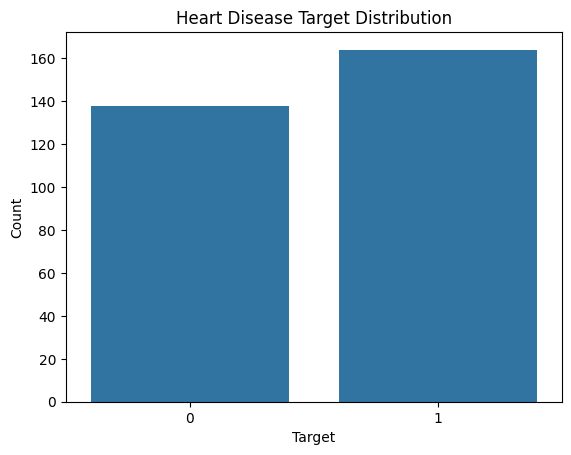

Percentage of targets with heart disease: 54.30%
Percentage of targets without heart disease: 45.70%


In [121]:
sns.countplot(data=df, x="target")
plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

print(f"Percentage of targets with heart disease: {df[df['target']==1].shape[0]/len(df)*100:.2f}%")
print(f"Percentage of targets without heart disease: {df[df['target']==0].shape[0]/len(df)*100:.2f}%")

## Train and Analyze the Models

### Break the dataset for 80% Training, and 20% Test

In [135]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### a) Logistic Regression Model

#### 1. Train the Model

In [136]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

#### 2. Test the model

In [166]:
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

df = pd.DataFrame({
    'Probability': y_prob_log,
    'Prediction': y_pred_log,
    'Actual': y_test
})

df

,Probability,Prediction,Actual
245,0.882545,1,1
349,0.741698,1,0
135,0.040497,0,0
389,0.576753,1,1
66,0.531353,1,1
...,...,...,...
402,0.503077,1,1
123,0.892054,1,1
739,0.391310,0,0
274,0.106535,0,1


### b) Decission Tree Model

#### 1. Train the Model

In [174]:
dec_tree_model = DecisionTreeClassifier(max_depth = 4, random_state=42)
dec_tree_model.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

#### 2. Test the Model

In [176]:
y_pred_dec_tree = dec_tree_model.predict(X_test_scaled)
y_prob_dec_tree = dec_tree_model.predict_proba(X_test_scaled)[:, 1]

df = pd.DataFrame({
    'Probability': y_prob_dec_tree,
    'Prediction': y_pred_dec_tree,
    'Actual': y_test
})

df

,Probability,Prediction,Actual
245,0.971831,1,1
349,0.900000,1,0
135,0.018519,0,0
389,0.000000,0,1
66,0.971831,1,1
...,...,...,...
402,0.551724,1,1
123,0.900000,1,1
739,0.133333,0,0
274,0.018519,0,1


## Evaluate the models

### 1. Accuracy Score

#### a) Logistic Regression

In [187]:
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log:.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_log)}")

Logistic Regression Accuracy: 0.7705
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61



#### b) Decision Tree

In [ ]:
accuracy_dec_tree = accuracy_score(y_test, y_pred_dec_tree)
print(f"Decision Tree Accuracy: {accuracy_dec_tree:.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_dec_tree)}")

Decision Tree Accuracy: 0.7377
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74        32
           1       0.71      0.76      0.73        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



### 2. Confusion Matrix

#### a) Logistic Regression

Confusion Matrix:
[[21 11]
 [ 3 26]]


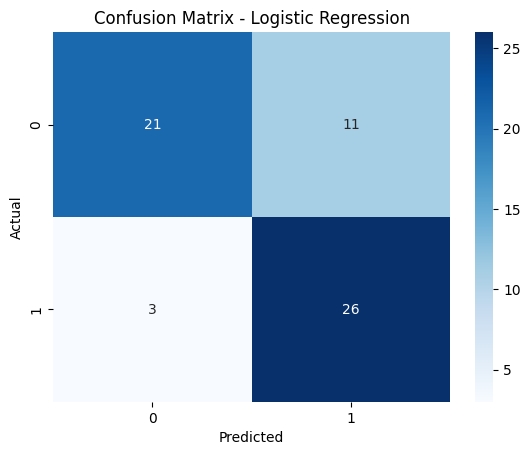

In [191]:
cm_log = confusion_matrix(y_test, y_pred_log)
print(f"Confusion Matrix:\n{cm_log}")

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### b) Decision Tree

Confusion Matrix:
[[23  9]
 [ 7 22]]


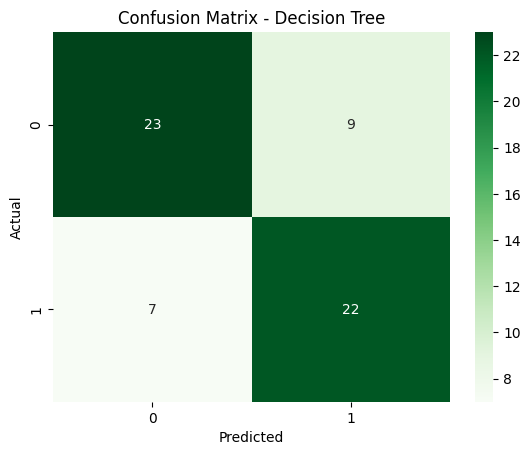

In [190]:

cm_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)
print(f"Confusion Matrix:\n{cm_dec_tree}")

sns.heatmap(cm_dec_tree, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 3. ROC Curve

#### a) Logistic Regression

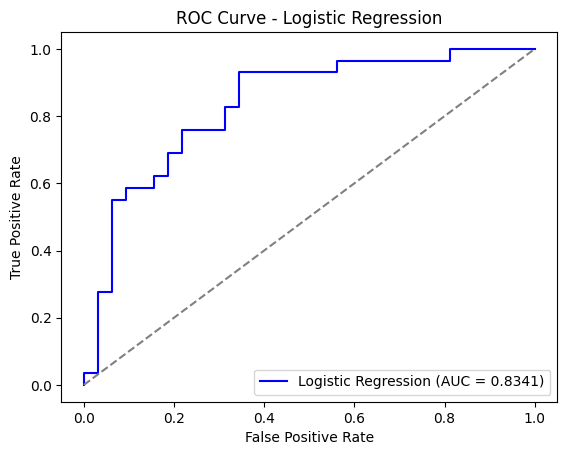

In [207]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
roc_auc_log = roc_auc_score(y_test, y_prob_log)

plt.plot(fpr, tpr, color = 'blue', label=f'Logistic Regression (AUC = {roc_auc_log:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### b) Decision Tree

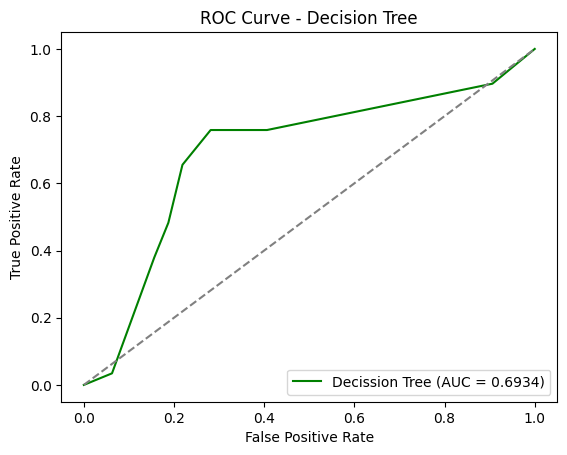

In [186]:
fpr, tpr, _ = roc_curve(y_test, y_prob_dec_tree)
roc_auc_dec_tree = roc_auc_score(y_test, y_prob_dec_tree)

plt.plot(fpr, tpr, color='green', label=f'Decission Tree (AUC = {roc_auc_dec_tree:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc="lower right")
plt.show()

## Important Features

### a) Logistic Regression

In [196]:
importance_log = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": log_model.coef_[0]
})

importance_log['Absolute Importance'] = importance_log['Importance'].abs()

importance_log = importance_log.sort_values(
    by='Absolute Importance', ascending=False
)

importance_log

,Feature,Importance,Absolute Importance
2,cp,1.003914,1.003914
1,sex,-0.855829,0.855829
9,oldpeak,-0.795716,0.795716
11,ca,-0.589434,0.589434
3,trestbps,-0.557168,0.557168
6,restecg,0.495707,0.495707
7,thalach,0.480636,0.480636
12,thal,-0.383665,0.383665
10,slope,0.327888,0.327888
8,exang,-0.277384,0.277384


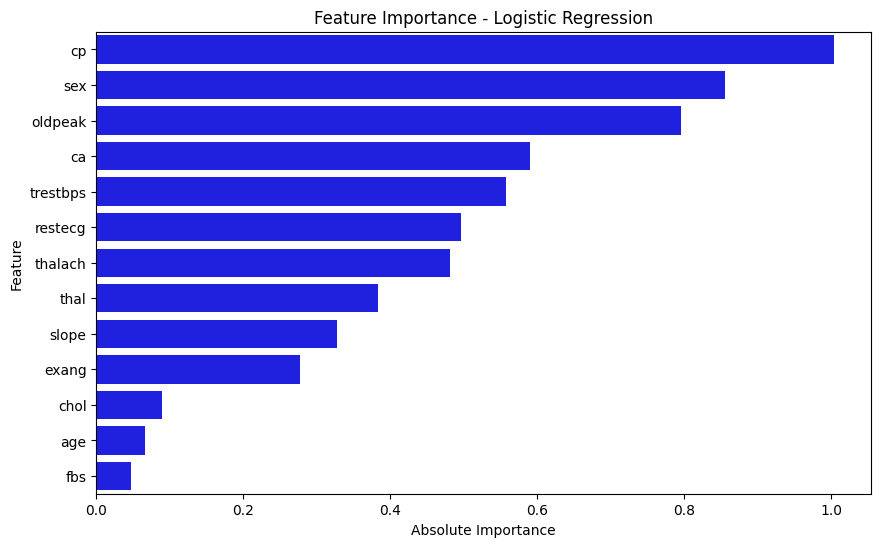

In [206]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_log,
    x="Absolute Importance",
    y="Feature",
    color='blue'
)
plt.title("Feature Importance - Logistic Regression")
plt.show()

### b) Decision Tree

In [ ]:
importance_tree = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dec_tree_model.feature_importances_
})

importance_tree = importance_tree.sort_values(
    by="Importance",
    ascending=False
)

importance_tree

,Feature,Importance
2,cp,0.412067
9,oldpeak,0.203631
0,age,0.115665
11,ca,0.113599
3,trestbps,0.082197
1,sex,0.066097
4,chol,0.006743
5,fbs,0.000000
6,restecg,0.000000
8,exang,0.000000


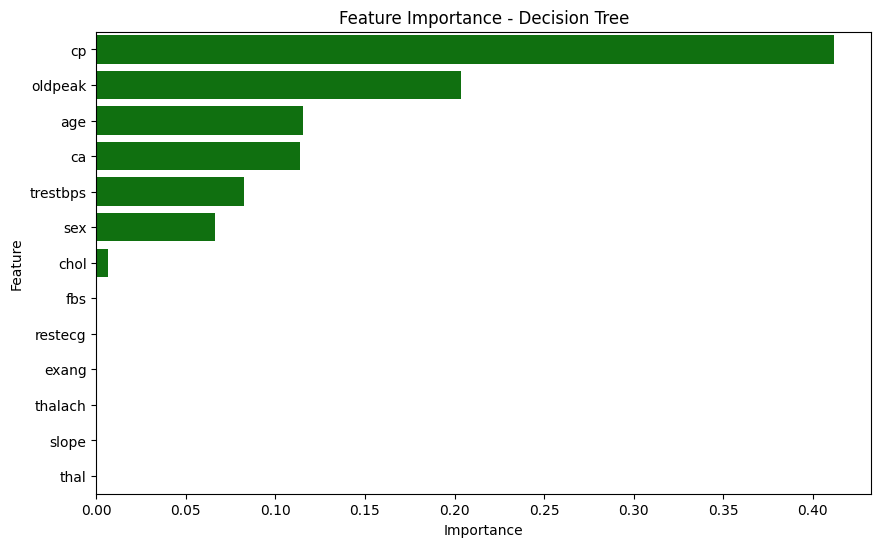

In [205]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_tree,
    x="Importance",
    y="Feature",
    color='green'
)
plt.title("Feature Importance - Decision Tree")
plt.show()